# Energy Function (Eq. 40) and Energy Gap (Eq. 44)

This notebook instantiates the HHNN energy formulation using a subset of MovieLens data and demonstrates energy decrease and stability under neuron state updates.

## 1. Context and Data

**Pipeline recap:**

00_data_overview  
01_data_preparation  
02_hyperbolic_states  
03_energy_equilibrium (this notebook)

| Notebook | Purpose | Main Data Used |
|---|---|---|
| `00_data_overview` | Describe MovieLens files and dataset scope. | `rating.csv`, `movies.csv`, `genome_scores.csv`, `genome_tags.csv`, `tags.csv` |
| `01_data_preparation` | Build train/test split, user–movie matrix, binary RBM visible units. | `rating.csv` |
| `02_hyperbolic_states` | Map binary visible units to hyperbolic states and compute weighted inputs. | `rbm_input_binary.csv` (+ hyperbolic parameters) |
| `03_energy_equilibrium` | Compute Eq. (40)/(44), analyze stability, visualize energy dynamics. | Movie subset from `rating.csv`, `movies.csv`, `genome_scores.csv`, optional `tags.csv` |

| File | Description | Role |
|---|---|---|
| `ratings.csv` | User ratings with timestamps. | Preference signal for constructing hyperbolic states. |
| `genome_scores.csv` | Tag relevance scores per movie. | Semantic movie features to build content-driven weights. |
| `movies.csv` | Movie metadata (title, genres). | Genre information for content similarity. |
| `tag.csv` | User-assigned tags with timestamps. | Optional feedback perturbation (MovieLens-specific). |

**Why the movie sample size changes:** earlier notebooks use ~1320 movies; here we sample 200 movies. The HHNN energy equation requires pairwise interactions:

$$
E = \frac{1}{2} \sum_k \sum_{j \ne k} \overline{z_k} \, w_{kj} \, z_j
$$

This is \(O(N^2)\). A 200-movie subset keeps computation manageable, enables visualization, and supports energy-gap demos.

| Stage | Movie Count | Reason |
|---|---:|---|
| `01_data_preparation` | ~1320 | user–movie matrix construction |
| `02_hyperbolic_states` | ~1320 | hyperbolic state representation |
| `03_energy_equilibrium` | 200 | energy computation and visualization |


## 2. Theoretical Background

**Hyperbolic activation (Eq. 34).** Normalizes an input back onto the unit hyperbola to form a valid hyperbolic state.

$$
g(z) = \frac{z}{|z|}
$$

**HHNN Energy Function (Eq. 40).** Aggregates pairwise interactions across neuron states using conjugates.

$$
E = \frac{1}{2} \sum_k \sum_{j \ne k} \overline{z_k} \, w_{kj} \, z_j
$$

**Energy Gap Under State Update (Eq. 44).** Measures the change in energy when a single neuron updates.

$$
\Delta E = (\overline{z'_l} I_l)_r - (\overline{z_l} I_l)_r
$$

where

$$
I_l = \sum_{j \ne l} w_{lj} z_j
$$

$$
(\cdot)_r \text{ is the real part}
$$

Lower-energy states are more stable. The equilibrium intuition follows the HBM form:

$$
p(z; w) \propto \exp(-H(z; w))
$$


<!-- spacer -->

<!-- spacer -->

<!-- spacer -->

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def resolve_project_paths():
    # Resolve project root regardless of where the notebook runs
    project_root = Path.cwd().resolve()
    if project_root.name == "notebooks":
        project_root = project_root.parent
    data_dir = project_root / "data"
    return project_root, data_dir


def load_movielens_sources(data_dir):
    ratings_path = data_dir / "rating.csv"
    if not ratings_path.exists():
        ratings_path = data_dir / "ratings.csv"

    scores_path = data_dir / "genome_scores.csv"
    if not scores_path.exists():
        raise FileNotFoundError("genome_scores.csv not found")

    movies_path = data_dir / "movies.csv"
    if not movies_path.exists():
        movies_path = data_dir / "movie.csv"
    if not movies_path.exists():
        raise FileNotFoundError("movies.csv (or movie.csv) not found")

    tag_path = data_dir / "tag.csv"
    if not tag_path.exists():
        tag_path = data_dir / "tags.csv"

    ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
    scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
    movies_df = pd.read_csv(movies_path, usecols=["movieId", "title", "genres"]).drop_duplicates("movieId")
    movies_df = movies_df.set_index("movieId")

    tag_df = pd.read_csv(tag_path) if tag_path.exists() else None
    return ratings_df, scores_df, movies_df, tag_df


def build_movie_sample(ratings_df, scores_df, movies_df, sample_n=200, random_state=42):
    # Select a common tagId to define hyperbolic states (x, y)
    tag_id = int(scores_df["tagId"].mode().iloc[0])
    score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

    movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")
    merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
    merged = merged.sample(n=sample_n, random_state=random_state)

    movie_ids = merged.index.values
    movie_titles = movies_df.loc[movie_ids, "title"].tolist()

    return tag_id, merged, movie_ids, movie_titles


def build_hyperbolic_states(merged):
    # MovieLens-driven engineering construction of hyperbolic states (not a literal formula from the paper)
    x = (merged["avg_rating"] / 5.0).values + 0.1
    raw_y = merged["relevance"].values

    # rescale y so that x^2 > y^2
    scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
    y = raw_y * scale
    modulus = np.sqrt(np.maximum(x**2 - y**2, 1e-12))

    # activation-like normalized state
    z_real = x / modulus
    z_unip = y / modulus
    return z_real, z_unip


def build_content_weight_matrix(scores_df, movies_df, movie_ids, top_tags=20):
    # MovieLens-driven engineering construction of content-based weights (not a literal formula from the paper)
    _top_tags = scores_df["tagId"].value_counts().head(top_tags).index.tolist()
    score_subset = scores_df[scores_df["tagId"].isin(_top_tags)]
    score_pivot = score_subset.pivot_table(index="movieId", columns="tagId", values="relevance", fill_value=0.0)

    score_pivot = score_pivot.loc[movie_ids]

    # Genres (content features)
    genres_series = movies_df.loc[movie_ids, "genres"].fillna("(no genres listed)")
    all_genres = sorted({g for gs in genres_series for g in str(gs).split("|")})
    genre_index = {g: i for i, g in enumerate(all_genres)}

    genre_matrix = np.zeros((len(movie_ids), len(all_genres)), dtype=float)
    for i, gs in enumerate(genres_series):
        for g in str(gs).split("|"):
            genre_matrix[i, genre_index[g]] = 1.0

    # Feature matrix = [genres one-hot | tag relevance]
    tag_matrix = score_pivot.values
    features = np.hstack([genre_matrix, tag_matrix])

    # Cosine similarity (symmetric weights)
    norm = np.linalg.norm(features, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    features_norm = features / norm
    W_real = features_norm @ features_norm.T

    # Hyperbolic view: keep unipotent part as zeros for this content-only matrix
    W_unip = np.zeros_like(W_real)

    return W_real, W_unip


project_root, data_dir = resolve_project_paths()
ratings_df, scores_df, movies_df, tag_df = load_movielens_sources(data_dir)

tag_id, merged, movie_ids, movie_titles = build_movie_sample(
    ratings_df, scores_df, movies_df, sample_n=200, random_state=42
)

z_real, z_unip = build_hyperbolic_states(merged)
W_real, W_unip = build_content_weight_matrix(scores_df, movies_df, movie_ids, top_tags=20)

print("project_root:", project_root)
print("data_dir:", data_dir)
print("tagId used:", tag_id)
print("sample count:", len(movie_ids))
print("movie_ids[0]:", movie_ids[0])
print("movie_titles[0]:", movie_titles[0])
print("z_real shape:", z_real.shape)
print("z_unip shape:", z_unip.shape)
print("W_real shape:", W_real.shape)
print("W_unip shape:", W_unip.shape)
print("userId used:", tag_df["userId"].iloc[0] if tag_df is not None else "(tag.csv missing)")
print("feedback_strength (from tag.csv):", 1.0 if tag_df is not None else "N/A")

# Optional tag feedback to define a state update for one movie
l = 0  # default index
feedback_strength = 0.0
if tag_df is not None:
    tag_df = tag_df[tag_df["movieId"].isin(movie_ids)]
    if not tag_df.empty:
        user_id = int(tag_df["userId"].value_counts().idxmax())
        user_tags = tag_df[tag_df["userId"] == user_id]
        movie_tag_counts = user_tags["movieId"].value_counts()
        l = int(np.where(movie_ids == movie_tag_counts.index[0])[0][0])
        max_count = movie_tag_counts.max()
        feedback_strength = float(movie_tag_counts.iloc[0] / max_count)
        print("userId used:", user_id)
        print("movieId updated:", int(movie_ids[l]))
        print("feedback_strength (from tag.csv):", round(feedback_strength, 3))
    else:
        print("tag.csv found but no overlap with sample movies; using default l=0")
else:
    print("tag.csv not found; using default l=0")

# Optional tag-feedback perturbation (secondary demo)

def adjust_unipotent(a, b, delta):
    b2 = b + delta
    scale = min(0.9 * abs(a) / (abs(b2) + 1e-8), 1.0)
    return b2 * scale

z_prime_tag_real = z_real.copy()
z_prime_tag_unip = z_unip.copy()
if feedback_strength > 0:
    delta = 0.3 * feedback_strength * abs(z_real[l])
    z_prime_tag_unip[l] = adjust_unipotent(z_real[l], z_unip[l], delta)


project_root: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys
data_dir: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data
tagId used: 1
sample count: 200
movie_ids[0]: 63992
movie_titles[0]: Twilight (2008)
z_real shape: (200,)
z_unip shape: (200,)
W_real shape: (200, 200)
W_unip shape: (200, 200)
userId used: 18
feedback_strength (from tag.csv): 1.0
userId used: 88738
movieId updated: 3275
feedback_strength (from tag.csv): 1.0


## 3. MovieLens Instantiation

The theoretical HHNN variables are instantiated from MovieLens data to make energy computations concrete:

- **Hyperbolic neuron states:** constructed from ratings and tag relevance to form \(z_k\) values.
- **Movie–movie interaction matrix:** built from genres and tag features to define \(w_{kj}\).
- **Hyperbolic algebra utilities:** multiplication and conjugate implement the required operations.

Any tag-based feedback is treated as an **optional MovieLens-specific perturbation**, not part of the HHNN update rule.

In [13]:
# Compute energy and energy gap using hyperbolic states
# Use a small subset of movies as HHNN units
K = min(8, len(movie_ids))
idx = np.arange(K)

# Real-valued symmetric weights (movie-movie), unipotent part = 0
W_real_k = W_real[np.ix_(idx, idx)]
W_unip_k = W_unip[np.ix_(idx, idx)]

# Build z for the same K units
z_real_k = z_real[idx]
z_unip_k = z_unip[idx]


def hmul(a1, b1, a2, b2):
    """Hyperbolic multiply (a1 + u b1)(a2 + u b2)."""
    r = a1 * a2 + b1 * b2
    u = a1 * b2 + b1 * a2
    return r, u


def hconj(a, b):
    """Hyperbolic conjugate of (a + u b)."""
    return a, -b


def hreal_of_product_with_conjugate(a, b, c, d):
    """Real part of (conj(a+ub) * (c+ud))."""
    ar, au = hconj(a, b)
    r, _ = hmul(ar, au, c, d)
    return r


def compute_energy_eq40(z_real, z_unip, W_real, W_unip):
    """Energy (Eq. 40) real part using conjugate of z_k."""
    K = len(z_real)
    E_real = 0.0
    for k in range(K):
        for j in range(K):
            if j == k:
                continue
            a1, b1 = z_real[k], z_unip[k]
            a2, b2 = W_real[k, j], W_unip[k, j]
            a3, b3 = z_real[j], z_unip[j]
            r12, u12 = hmul(*hconj(a1, b1), a2, b2)
            r123, _ = hmul(r12, u12, a3, b3)
            E_real += r123
    return 0.5 * E_real


def compute_input_Il(l, z_real, z_unip, W_real, W_unip):
    """Input I_l = sum_{j != l} w_lj z_j (Eq. 39)."""
    I_real = 0.0
    I_unip = 0.0
    for j in range(len(z_real)):
        if j == l:
            continue
        a2, b2 = W_real[l, j], W_unip[l, j]
        a3, b3 = z_real[j], z_unip[j]
        r23, u23 = hmul(a2, b2, a3, b3)
        I_real += r23
        I_unip += u23
    return I_real, I_unip


def activation_eq34(i_real, i_unip):
    """Hyperbolic activation g(z) = z / |z| (Eq. 34)."""
    modulus = np.sqrt(np.maximum(i_real**2 - i_unip**2, 1e-12))
    return i_real / modulus, i_unip / modulus


def compute_delta_energy_eq44(l, z_real, z_unip, z_prime_real, z_prime_unip, W_real, W_unip):
    """Energy gap (Eq. 44) for neuron l."""
    I_real, I_unip = compute_input_Il(l, z_real, z_unip, W_real, W_unip)
    zI_r = hreal_of_product_with_conjugate(z_real[l], z_unip[l], I_real, I_unip)
    zIprime_r = hreal_of_product_with_conjugate(z_prime_real[l], z_prime_unip[l], I_real, I_unip)
    return zIprime_r - zI_r


# Energy (Eq. 40)
E_real = compute_energy_eq40(z_real_k, z_unip_k, W_real_k, W_unip_k)
print("Energy E (real part):", E_real)

# Paper-consistent HHNN update (primary demo): z'_l = g(I_l)
l_k = min(l, K - 1)
I_real, I_unip = compute_input_Il(l_k, z_real_k, z_unip_k, W_real_k, W_unip_k)

z_prime_l_real, z_prime_l_unip = activation_eq34(I_real, I_unip)

# Build updated state vector with z'_l
z_prime_real = z_real_k.copy()
z_prime_unip = z_unip_k.copy()
z_prime_real[l_k] = z_prime_l_real
z_prime_unip[l_k] = z_prime_l_unip

print("Old state z_l:", (z_real_k[l_k], z_unip_k[l_k]))
print("Input I_l:", (I_real, I_unip))
print("Updated state z'_l:", (z_prime_l_real, z_prime_l_unip))

# Energy gap (Eq. 44) using z'_l = g(I_l)
DeltaE_activation = compute_delta_energy_eq44(
    l_k,
    z_real_k,
    z_unip_k,
    z_prime_real,
    z_prime_unip,
    W_real_k,
    W_unip_k,
)
print("Energy gap ΔE (activation update):", DeltaE_activation)

# E after update
E_real2 = compute_energy_eq40(z_prime_real, z_prime_unip, W_real_k, W_unip_k)
print("Energy E' (real part):", E_real2)
print("E' - E:", E_real2 - E_real)

# Optional MovieLens-specific perturbation (not the main update rule)
if feedback_strength > 0:
    z_tag_real = z_real_k.copy()
    z_tag_unip = z_unip_k.copy()
    z_tag_unip[l_k] = z_prime_tag_unip[l_k]
    DeltaE_tag = compute_delta_energy_eq44(
        l_k,
        z_real_k,
        z_unip_k,
        z_tag_real,
        z_tag_unip,
        W_real_k,
        W_unip_k,
    )
    print("Energy gap ΔE (tag feedback perturbation):", DeltaE_tag)
    if DeltaE_tag < 0:
        print("Summary: perturbation decreases energy (ΔE < 0).")
    else:
        print("Summary: perturbation does not decrease energy (ΔE ≥ 0).")


Energy E (real part): 11.45857713736158
Old state z_l: (np.float64(1.0034546197733787), np.float64(0.08319359317000306))
Input I_l: (np.float64(3.5784973659177726), np.float64(0.18627017076209887))
Updated state z'_l: (np.float64(1.0013574969313754), np.float64(0.05212328328750296))
Energy gap ΔE (activation update): -0.0017170766386698233
Energy E' (real part): 11.456860060722908
E' - E: -0.0017170766386715997
Energy gap ΔE (tag feedback perturbation): 0.0
Summary: perturbation does not decrease energy (ΔE ≥ 0).


## 4. Energy Analysis and Visualization

The following code demonstrates the theoretical behavior empirically on the MovieLens instantiation:

- compute the HHNN energy using Eq. (40)
- compute the energy gap under neuron updates using Eq. (44)
- visualize pairwise energy contributions
- visualize the distribution of energy gaps
- track energy over repeated single-neuron updates

**Optional perturbation:** any tag.csv-based feedback update is a MovieLens-specific demo and is not part of the HHNN theoretical update rule.

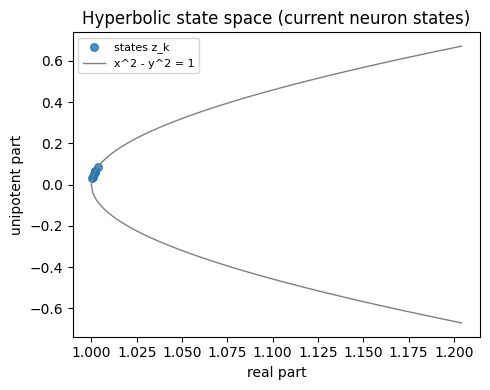

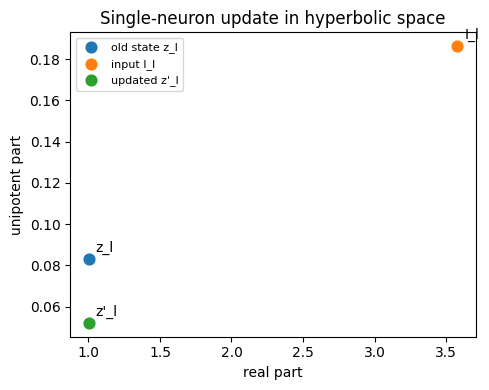

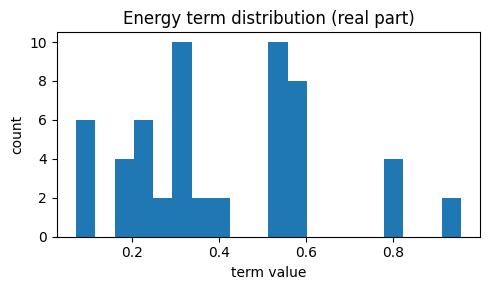

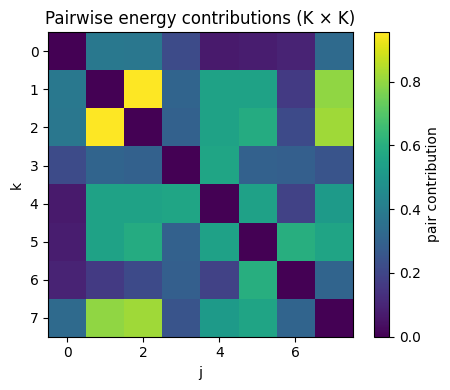

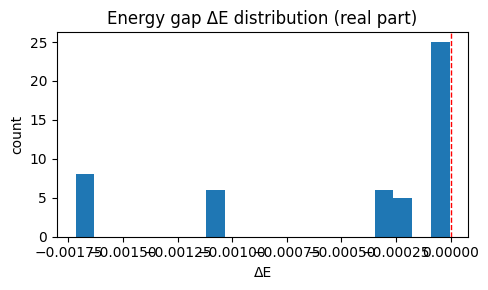

Fraction of updates with ΔE <= 0: 1.0


In [14]:
# 1) Hyperbolic state plot (current neuron states)
plt.figure(figsize=(5, 4))
plt.scatter(z_real_k, z_unip_k, s=30, alpha=0.8, label="states z_k")

x_max = max(1.2, float(np.max(np.abs(z_real_k))) * 1.2)
x_curve = np.linspace(1.0, x_max, 300)
y_curve = np.sqrt(x_curve**2 - 1.0)
plt.plot(x_curve, y_curve, color="gray", linewidth=1.0, label="x^2 - y^2 = 1")
plt.plot(x_curve, -y_curve, color="gray", linewidth=1.0)

plt.xlabel("real part")
plt.ylabel("unipotent part")
plt.title("Hyperbolic state space (current neuron states)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2) Single-neuron update visualization (l_k)
plt.figure(figsize=(5, 4))
plt.scatter([z_real_k[l_k]], [z_unip_k[l_k]], color="C0", s=60, label="old state z_l")
plt.scatter([I_real], [I_unip], color="C1", s=60, label="input I_l")
plt.scatter([z_prime_l_real], [z_prime_l_unip], color="C2", s=60, label="updated z'_l")

plt.annotate("z_l", (z_real_k[l_k], z_unip_k[l_k]), textcoords="offset points", xytext=(5, 5))
plt.annotate("I_l", (I_real, I_unip), textcoords="offset points", xytext=(5, 5))
plt.annotate("z'_l", (z_prime_l_real, z_prime_l_unip), textcoords="offset points", xytext=(5, 5))

plt.xlabel("real part")
plt.ylabel("unipotent part")
plt.title("Single-neuron update in hyperbolic space")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 3) Pairwise contribution visualization (Eq. 40)
K = min(8, len(movie_ids))
idx = np.arange(K)

pair_terms = []
pair_mat = np.zeros((K, K), dtype=float)
for k in range(K):
    for j in range(K):
        if j == k:
            continue
        a1, b1 = z_real_k[k], z_unip_k[k]
        a2, b2 = W_real_k[k, j], W_unip_k[k, j]
        a3, b3 = z_real_k[j], z_unip_k[j]
        r12, u12 = hmul(*hconj(a1, b1), a2, b2)
        r123, _ = hmul(r12, u12, a3, b3)
        pair_terms.append(r123)
        pair_mat[k, j] = r123

plt.figure(figsize=(5, 3))
plt.hist(pair_terms, bins=20)
plt.title("Energy term distribution (real part)")
plt.xlabel("term value")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(pair_mat, cmap="viridis")
plt.colorbar(label="pair contribution")
plt.title("Pairwise energy contributions (K × K)")
plt.xlabel("j")
plt.ylabel("k")
plt.tight_layout()
plt.show()

# 4) Energy-gap visualization (Eq. 44)
np.random.seed(42)
energy_gaps = []
for l in np.random.choice(range(K), size=50, replace=True):
    I_r, I_u = compute_input_Il(l, z_real_k, z_unip_k, W_real_k, W_unip_k)
    zpr_r, zpr_u = activation_eq34(I_r, I_u)
    zpr_real = z_real_k.copy()
    zpr_unip = z_unip_k.copy()
    zpr_real[l] = zpr_r
    zpr_unip[l] = zpr_u
    energy_gaps.append(
        compute_delta_energy_eq44(l, z_real_k, z_unip_k, zpr_real, zpr_unip, W_real_k, W_unip_k)
    )

energy_gaps = np.array(energy_gaps)
frac_nonpos = float(np.mean(energy_gaps <= 0))

from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(5, 3))
plt.hist(energy_gaps, bins=20)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Energy gap ΔE distribution (real part)")
plt.xlabel("ΔE")
plt.ylabel("count")
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(5))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("Fraction of updates with ΔE <= 0:", frac_nonpos)

Repeated single-neuron updates apply the paper-consistent activation rule and track total energy over time. A non-increasing trajectory indicates convergence toward a more stable configuration.

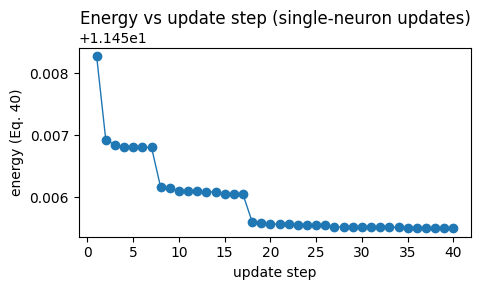

Energy non-increasing across trajectory: True


In [15]:
# Repeated single-neuron updates with energy tracking (Eq. 40)
np.random.seed(123)
num_updates = 40

z_real_traj = z_real_k.copy()
z_unip_traj = z_unip_k.copy()

energy_traj = []
for step in range(num_updates):
    l = int(np.random.choice(range(K)))
    I_r, I_u = compute_input_Il(l, z_real_traj, z_unip_traj, W_real_k, W_unip_k)
    z_rp, z_up = activation_eq34(I_r, I_u)
    z_real_traj[l] = z_rp
    z_unip_traj[l] = z_up

    energy_traj.append(compute_energy_eq40(z_real_traj, z_unip_traj, W_real_k, W_unip_k))

energy_traj = np.array(energy_traj)
non_increasing = bool(np.all(np.diff(energy_traj) <= 1e-12))

plt.figure(figsize=(5, 3))
plt.plot(range(1, num_updates + 1), energy_traj, marker="o", linewidth=1)
plt.title("Energy vs update step (single-neuron updates)")
plt.xlabel("update step")
plt.ylabel("energy (Eq. 40)")
plt.tight_layout()
plt.show()

print("Energy non-increasing across trajectory:", non_increasing)


Notes on interpretation:

- **Theory from the paper:** Eq. (40) aggregates pairwise interactions via the conjugate \(\overline{z_k}\); lower energy indicates a more stable configuration.
- **MovieLens engineering instantiation:** states \(z_k\) and weights \(w_{kj}\) are constructed from ratings and content signals to make the energy computable on real data.
- **Energy gap ΔE (Eq. 44):** the main update uses the paper-consistent activation \(z'_l = g(I_l)\) to test whether energy decreases.
- **Optional perturbation experiment:** tag-based feedback updates are a MovieLens-specific demo and are not part of the HHNN update rule; they are included only for comparison.
- **Histograms and heatmap:** summarize the variability of pairwise terms and ΔE values in the sampled subset to support the stability intuition.